Import des differentes bibliotheques

In [7]:
from keras.models import Sequential
from keras. layers import Dense
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
from sklearn.model_selection import train_test_split
from main import *

données chargées : 
<bound method NDFrame.head of     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
644     MS   F   19       R     GT3       T     2     3  services     other   
645     MS   F   18       U     LE3       T     3     1   teacher  services   
646     MS   F   18       U     GT3       T     1     1     other     other   
647     MS   M   17       U     LE3       T     3     1  services  services   
648     MS   M   18       R     LE3       T     3     2  services     other   

 

Import des differentes données

In [19]:
data = pd.read_csv("données_transformées.csv", sep=";", skiprows=[0])

datatarget = data.iloc[:,-1]
dataclean = data.iloc[:,:-1]



Sepration des données

In [20]:
X_train, X_test, y_train, y_test = train_test_split(dataclean,datatarget, test_size=0.2, random_state=42)

scale les entrées

In [21]:
print("Taille de X_train :", X_train.shape)
print("Types des colonnes :\n", X_train.dtypes)

scaler =StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Taille de X_train : (518, 30)
Types des colonnes :
 0      int64
0.1    int64
18     int64
0.2    int64
0.3    int64
1      int64
4      int64
4.1    int64
3      int64
0.4    int64
2      int64
1.1    int64
2.1    int64
2.2    int64
0.5    int64
0.6    int64
1.2    int64
1.3    int64
1.4    int64
0.7    int64
0.8    int64
1.5    int64
1.6    int64
4.2    int64
3.1    int64
4.3    int64
1.7    int64
1.8    int64
3.2    int64
4.4    int64
dtype: object


CREATION du reseau MLP avec une seul note 

In [22]:
Model1 = Sequential()
Model1.add(Dense(10, activation='relu', input_dim=30))
Model1.add(Dense(5, activation='relu'))
Model1.add(Dense(1, activation='sigmoid'))

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
Model2 = Sequential()
Model2.add(Dense(5, activation='relu', input_dim=30))
Model2.add(Dense(3, activation='relu'))
Model2.add(Dense(1, activation='sigmoid'))

In [24]:
Model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
Model1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
Model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
Model2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 5)              │           155 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177 (708.00 B)

 Trainable params: 177 (708.00 B)

 Non-trainable params: 0 (0.00 B)

apprentissage

In [26]:
epochs = 100
history1 = Model1.fit(X_train_scaled, y_train, epochs=epochs)
history2 = Model2.fit(X_train_scaled, y_train, epochs=epochs)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6892 - loss: 0.7339
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6931 - loss: 0.6865 
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6931 - loss: 0.6527 
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6931 - loss: 0.6269 
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6988 - loss: 0.6055 
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6988 - loss: 0.5893 
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6969 - loss: 0.5746 
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6969 - loss: 0.5615 
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6950 - loss: 0.5495 
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6931 - loss: 0.5384 
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6950 - loss: 0.5274 
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step -

Prediction des notes

In [27]:
Predict1 = Model1.predict(X_test_scaled)
Predict2 = Model2.predict(X_test_scaled)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


presentation de la loss fonction durant l apprentissage

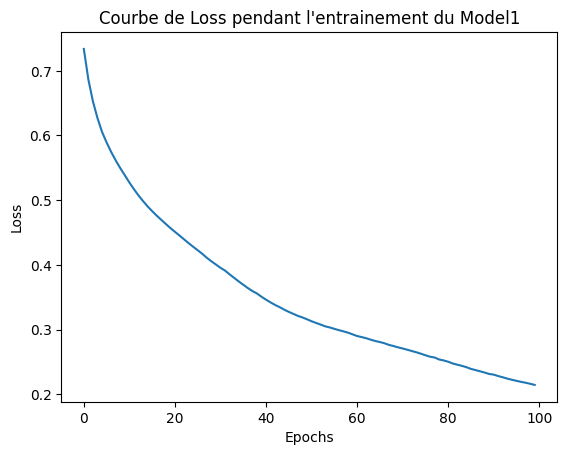

In [28]:
plt.plot(history1.history['loss'])
plt.title('Courbe de Loss pendant l\'entrainement du Model1')
plt.xlabel('Epochs')
plt.ylabel('Loss') 
plt.show()

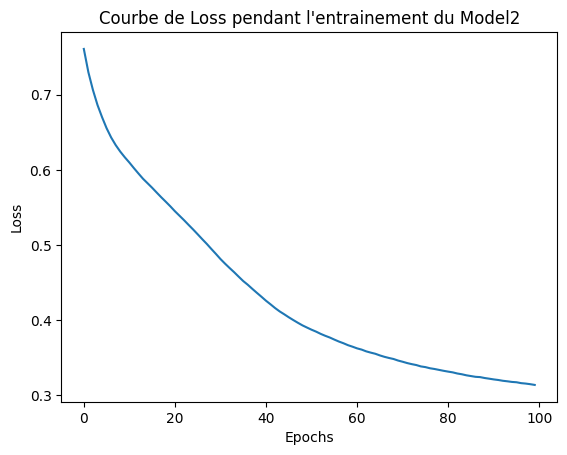

In [29]:
plt.plot(history2.history['loss'])
plt.title('Courbe de Loss pendant l\'entrainement du Model2')
plt.xlabel('Epochs')
plt.ylabel('Loss') 
plt.show()

fonction de la matrice de confusion

In [36]:
def afficher_matrice_confusion(cm,Type_model):
    """Affiche la matrice de confusion."""
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.title(f'Matrice de Confusion - {Type_model}')
    plt.show()






In [34]:
predictions_binary1 = (Predict1 > 0.5).astype(int)
predictions_binary2 = (Predict2 > 0.5).astype(int)


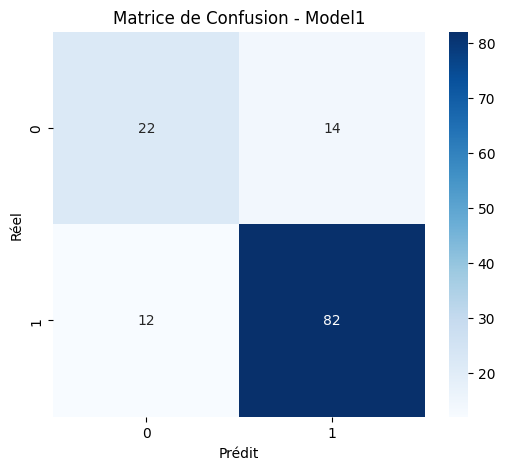

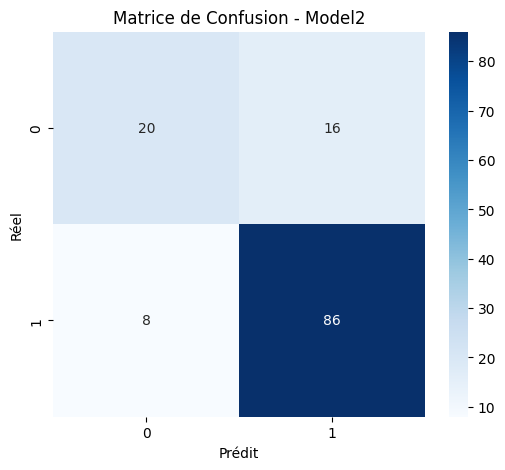

In [37]:

cm1 = confusion_matrix(y_test, predictions_binary1)
afficher_matrice_confusion(cm1,'Model1')


cm2 = confusion_matrix(y_test, predictions_binary2)
afficher_matrice_confusion(cm2,'Model2')